In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv(r"C:\Users\shrut\Downloads\archive (3).zip",encoding="latin1")

In [3]:
df.head(10)

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0
5,6,Vodafone,M,36,Uttarakhand,Chennai,120612,2020-01-01,1,73452,91,24,8109,0
6,7,BSNL,F,60,Karnataka,Delhi,609616,2020-01-01,1,110035,36,13,8512,0
7,8,BSNL,M,46,Arunachal Pradesh,Kolkata,866786,2020-01-01,4,104541,87,40,2245,1
8,9,Reliance Jio,F,53,Himachal Pradesh,Mumbai,765257,2020-01-01,2,79439,34,12,10039,0
9,10,BSNL,F,57,Rajasthan,Mumbai,506308,2020-01-01,0,126422,61,33,567,0


In [4]:
df.tail(10)

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
243543,243544,Airtel,M,73,Jharkhand,Kolkata,675783,2023-05-03,3,131421,10,20,8551,0
243544,243545,Reliance Jio,M,37,Uttar Pradesh,Delhi,712167,2023-05-03,1,30972,72,28,5053,0
243545,243546,Vodafone,M,64,Mizoram,Delhi,547404,2023-05-03,1,113699,71,23,9277,0
243546,243547,Airtel,M,51,Nagaland,Chennai,331867,2023-05-03,1,87843,78,43,7394,0
243547,243548,Vodafone,M,18,Haryana,Bangalore,184327,2023-05-03,4,111912,17,32,5944,0
243548,243549,Airtel,F,28,Mizoram,Kolkata,110295,2023-05-03,3,130580,28,9,4102,0
243549,243550,Reliance Jio,F,52,Assam,Kolkata,713481,2023-05-03,0,82393,80,45,7521,0
243550,243551,Reliance Jio,M,59,Tripura,Kolkata,520218,2023-05-03,4,51298,26,4,6547,0
243551,243552,BSNL,M,49,Madhya Pradesh,Kolkata,387744,2023-05-03,2,83981,80,15,1125,0
243552,243553,BSNL,F,37,Telangana,Hyderabad,139086,2023-05-04,0,144297,61,7,3384,0


In [5]:
df.shape

(243553, 14)

In [6]:
df.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='object')

In [7]:
df.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000,243553.000000
mean,121777.000000,46.077609,549501.270541,1.997500,85021.137839,49.010548,23.945404,4993.186025,0.200478
std,70307.839393,16.444029,259808.860574,1.414941,37508.963233,29.453556,14.733575,2942.019547,0.400359
min,1.000000,18.000000,100006.000000,0.000000,20000.000000,-10.000000,-5.000000,-987.000000,0.000000
25%,60889.000000,32.000000,324586.000000,1.000000,52585.000000,24.000000,11.000000,2490.000000,0.000000
50%,121777.000000,46.000000,548112.000000,2.000000,84990.000000,49.000000,24.000000,4987.000000,0.000000
75%,182665.000000,60.000000,774994.000000,3.000000,117488.000000,74.000000,36.000000,7493.000000,0.000000
max,243553.000000,74.000000,999987.000000,4.000000,149999.000000,108.000000,53.000000,10991.000000,1.000000


In [8]:
df.isnull().sum()

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [50]:
df['date_of_registration'] = pd.to_datetime(df['date_of_registration'])

In [51]:
df['registration_year'] = df['date_of_registration'].dt.year

df['registration_month'] = df['date_of_registration'].dt.month

In [10]:
df["churn"].value_counts()

churn
0    194726
1     48827
Name: count, dtype: int64

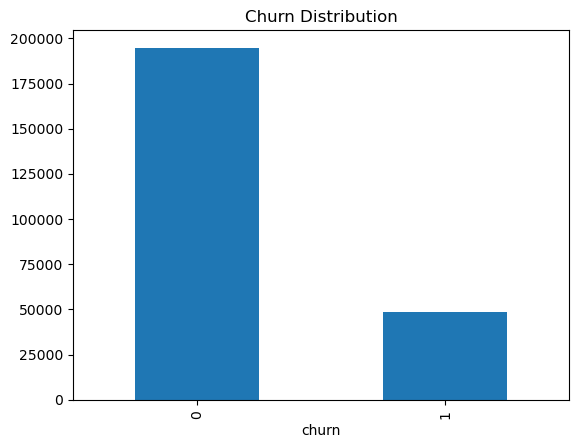

In [11]:
df["churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.show()

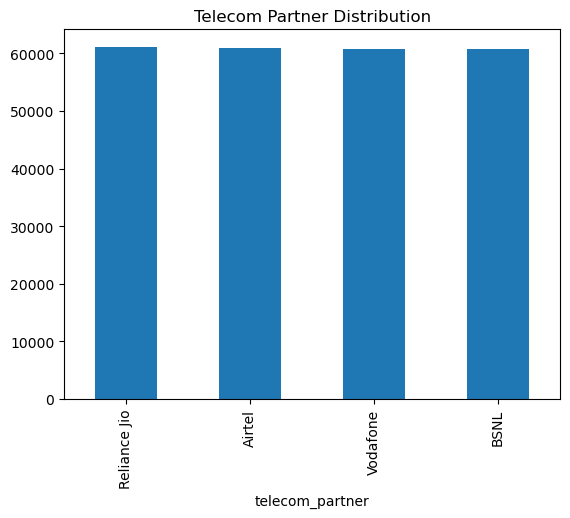

In [12]:
df["telecom_partner"].value_counts().plot(kind="bar")
plt.title("Telecom Partner Distribution")
plt.show()

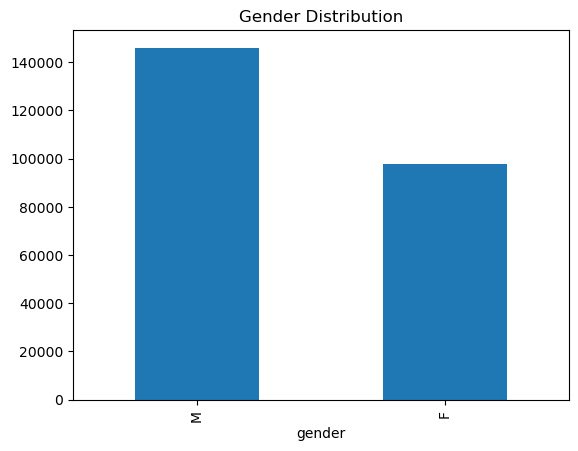

In [13]:
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()

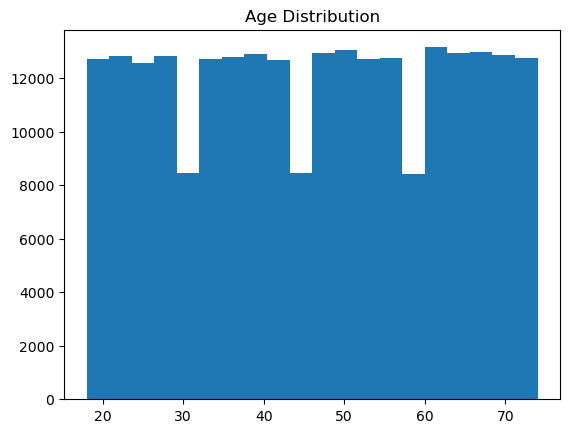

In [14]:
plt.hist(df["age"], bins=20)
plt.title("Age Distribution")
plt.show()

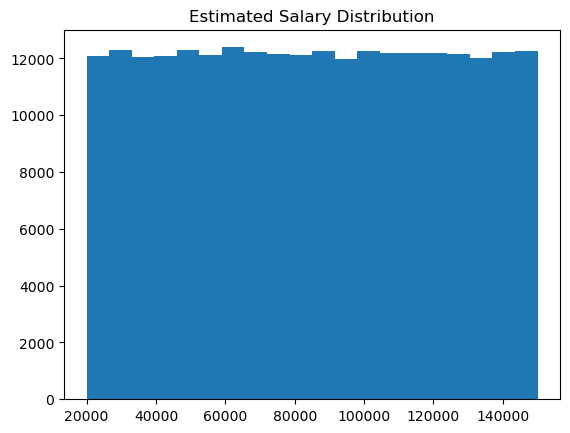

In [15]:
plt.hist(df["estimated_salary"], bins=20)
plt.title("Estimated Salary Distribution")
plt.show()

In [16]:
df["total_activity"] = (
    df["calls_made"]
    + df["sms_sent"]
    + df["data_used"]
)

In [17]:
df["salary_per_activity"] = (
    df["estimated_salary"]
    / (df["total_activity"] + 1)
)

In [18]:
df = pd.get_dummies(
    df,
    columns=[
        "telecom_partner",
        "gender",
        "state",
        "city"
    ],
    drop_first=True
)

In [19]:
X = df.drop(
    columns=[
        "customer_id",
        "date_of_registration",
        "pincode",
        "churn"
    ],
    errors="ignore"
)

y = df["churn"]

In [38]:
X_train=X_train.replace([np.inf,-np.inf],np.nan)
X_train=X_train.fillna(0)

X_test=X_test.replace([np.inf,-np.inf],np.nan)
X_test=X_test.fillna(0)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
import numpy as np

print(np.isinf(X).sum())

age                             0
num_dependents                  0
estimated_salary                0
calls_made                      0
sms_sent                        0
data_used                       0
total_activity                  0
salary_per_activity             0
telecom_partner_BSNL            0
telecom_partner_Reliance Jio    0
telecom_partner_Vodafone        0
gender_M                        0
state_Arunachal Pradesh         0
state_Assam                     0
state_Bihar                     0
state_Chhattisgarh              0
state_Goa                       0
state_Gujarat                   0
state_Haryana                   0
state_Himachal Pradesh          0
state_Jharkhand                 0
state_Karnataka                 0
state_Kerala                    0
state_Madhya Pradesh            0
state_Maharashtra               0
state_Manipur                   0
state_Meghalaya                 0
state_Mizoram                   0
state_Nagaland                  0
state_Odisha  

In [41]:
X = X.replace([np.inf, -np.inf], np.nan)

In [42]:
X = X.fillna(0)

In [43]:
print(np.isinf(X).sum().sum())
print(X.isnull().sum().sum())

0
0


In [48]:
model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

C:\Users\shrut\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [66]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,10
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
print("Accuracy:", accuracy_score(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy: 0.7995319332388988
[[38946     0]
 [ 9765     0]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711



C:\Users\shrut\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shrut\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shrut\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [69]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
2,estimated_salary,0.116041
7,salary_per_activity,0.113462
6,total_activity,0.110533
5,data_used,0.109241
3,calls_made,0.102654
0,age,0.094075
4,sms_sent,0.093211
1,num_dependents,0.037740
11,gender_M,0.013049
8,telecom_partner_BSNL,0.012488


In [55]:
model = LogisticRegression(max_iter=10)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

C:\Users\shrut\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [53]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.7995319332388988
[[38946     0]
 [ 9765     0]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711



C:\Users\shrut\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shrut\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shrut\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
